In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('default')
df = pd.read_csv("../data/cleaned_supply_chain_data.csv")

In [2]:
print("Rows: ", df.shape[0])
print("Columns: ", df.shape[1])
df.head()

Rows:  180519
Columns:  52


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Shipping_Duration,Order_Value,Profit_Margin,Estimated_Freight_Cost,High_Value_Order,Risk_Flag
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,327.75,0,2018-02-03 22:56:00,Standard Class,3,327.75,0.289095,32.22,1,1
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,327.75,0,2018-01-18 12:27:00,Standard Class,5,327.75,-0.797445,36.22,1,1
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,327.75,0,2018-01-17 12:06:00,Standard Class,4,327.75,-0.797438,34.22,1,1
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,327.75,0,2018-01-16 11:45:00,Standard Class,3,327.75,0.074752,32.22,1,1
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,327.75,0,2018-01-15 11:24:00,Standard Class,2,327.75,0.448488,30.22,1,1


In [3]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Department Id,Latitude,Longitude,...,Product Card Id,Product Category Id,Product Price,Product Status,Shipping_Duration,Order_Value,Profit_Margin,Estimated_Freight_Cost,High_Value_Order,Risk_Flag
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.0,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107609,0.548291,31.851451,6691.379495,5.443460,29.719955,-84.915675,...,692.509764,31.851451,141.232550,0.0,3.471856,203.772096,0.119381,23.245480,0.234612,0.654546
std,1.623722,1.374449,104.433526,120.043670,0.497664,15.640064,4162.918106,1.629246,9.813646,21.433241,...,336.446807,15.640064,139.732492,0.0,1.670471,132.273077,0.462602,11.105417,0.423758,0.475517
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,2.000000,-33.937553,-158.025986,...,19.000000,2.000000,9.990000,0.0,0.000000,9.990000,-2.744505,0.799200,0.000000,0.000000
25%,2.000000,2.000000,7.000000,104.379997,0.000000,18.000000,3258.500000,4.000000,18.265432,-98.446312,...,403.000000,18.000000,50.000000,0.0,2.000000,119.980003,0.073368,15.995200,0.000000,0.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,5.000000,33.144863,-76.847908,...,627.000000,29.000000,59.990002,0.0,3.000000,199.919998,0.268539,21.993600,0.000000,1.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9779.000000,7.000000,39.279617,-66.370583,...,1004.000000,45.000000,199.990005,0.0,5.000000,299.950008,0.360347,28.000000,0.000000,1.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,12.000000,48.781933,115.263077,...,1363.000000,76.000000,1999.989990,0.0,6.000000,1999.989990,0.499648,171.999199,1.000000,1.000000


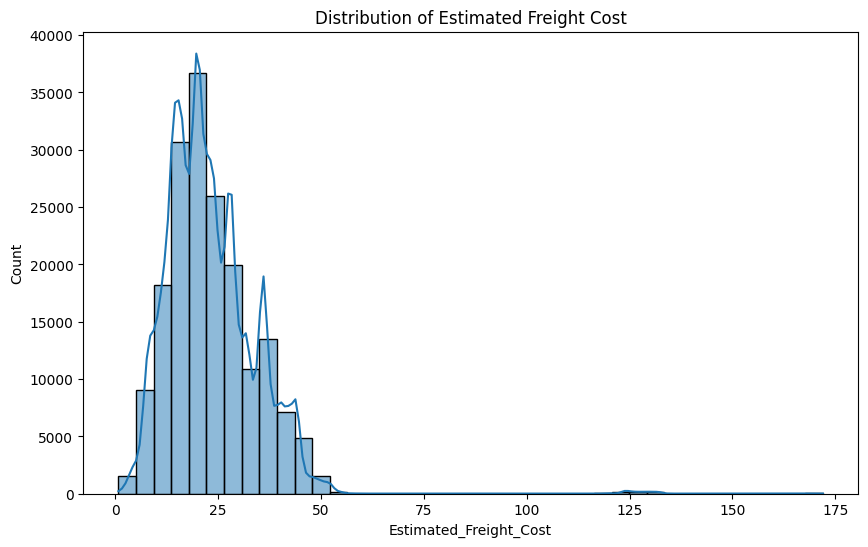

In [4]:
# Distribution of estimated freight cost
plt.figure(figsize=(10, 6))
sns.histplot(
    df['Estimated_Freight_Cost'],
    bins = 40,
    kde=True
)
plt.title('Distribution of Estimated Freight Cost')
plt.show()

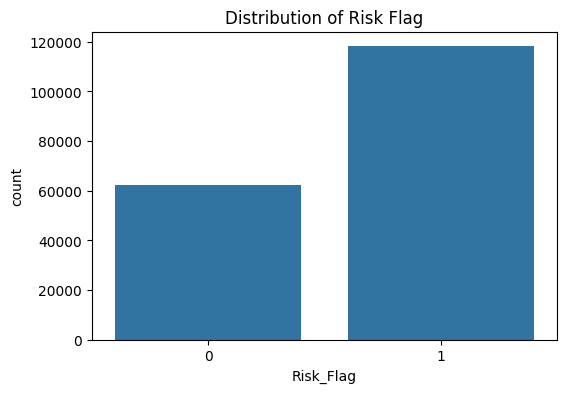

In [6]:
# Risk flag distribution
plt.figure(figsize=(6, 4))
sns.countplot(
    data = df,
    x = 'Risk_Flag'
)
plt.title('Distribution of Risk Flag')
plt.show()

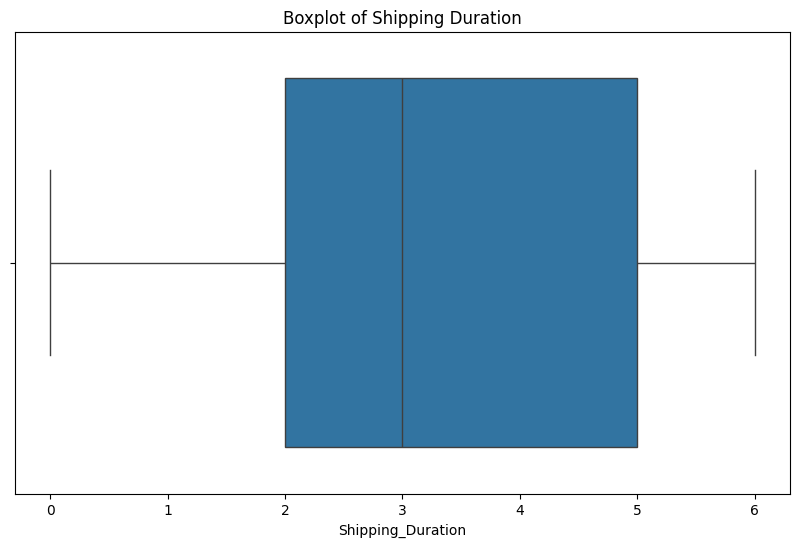

In [7]:
# Shipping duration analysis
plt.figure(figsize=(10, 6))
sns.boxplot(
    x = df['Shipping_Duration']
)
plt.title('Boxplot of Shipping Duration')
plt.show()

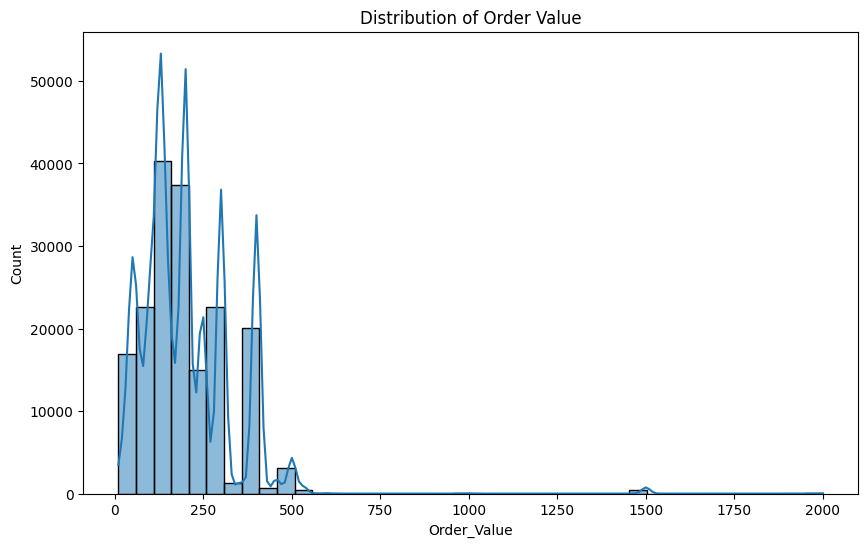

In [8]:
# Order value distribution
plt.figure(figsize=(10, 6))
sns.histplot(
    df['Order_Value'],
    bins = 40,
    kde = True
)
plt.title('Distribution of Order Value')
plt.show()

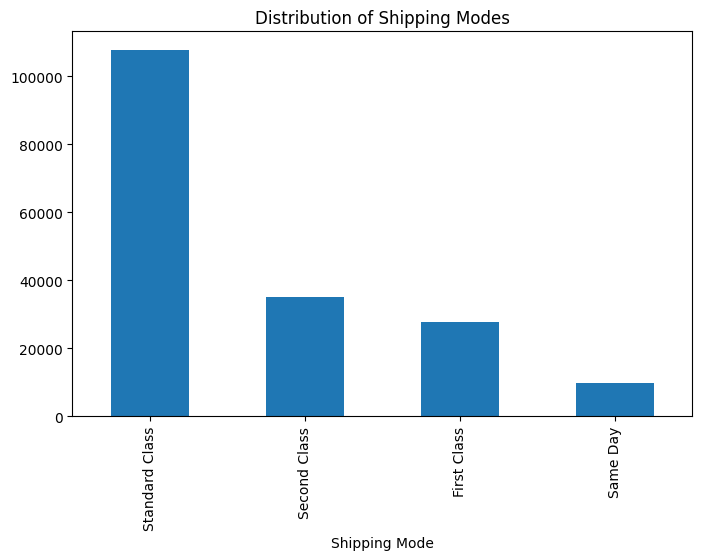

In [10]:
# Top shipping modes
plt.figure(figsize=(8, 5))
df['Shipping Mode'].value_counts().plot(kind='bar')
plt.title('Distribution of Shipping Modes')
plt.show()

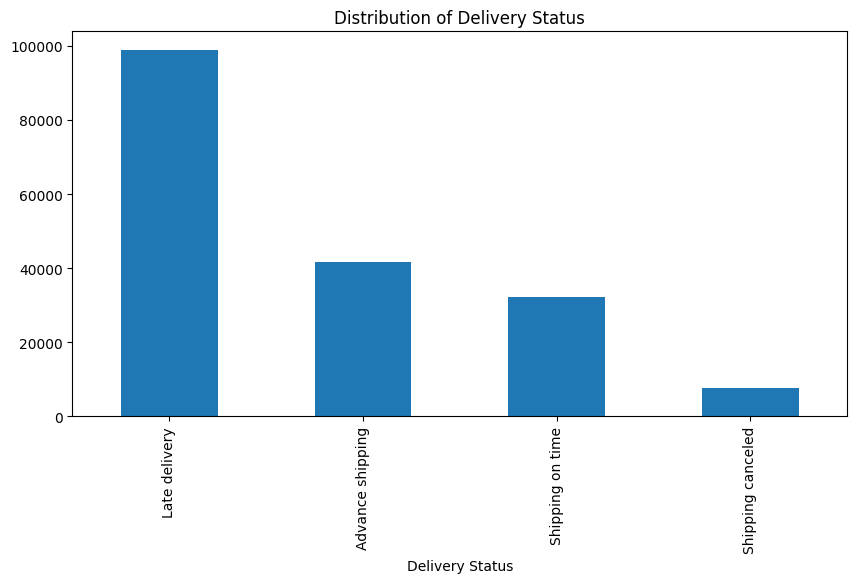

In [12]:
# Delivery status analysis
plt.figure(figsize=(10, 5))
df['Delivery Status'].value_counts().plot(kind='bar')
plt.title('Distribution of Delivery Status')
plt.show()


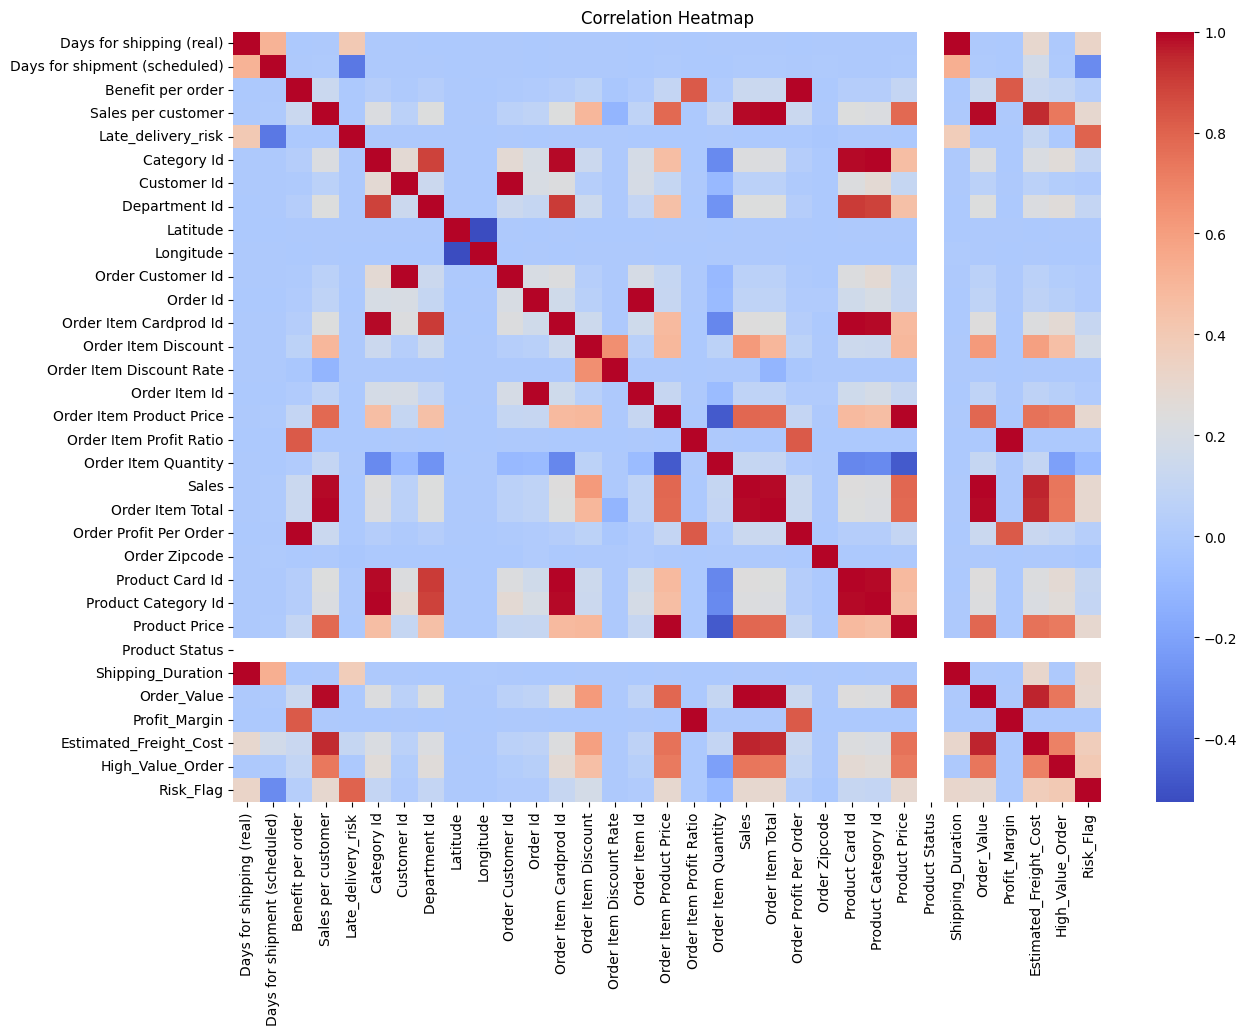

In [13]:
# Correlation analyis
numeric_diff = df.select_dtypes(include=[np.number])
corr = numeric_diff.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr, cmap = 'coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()

In [15]:
# Correlation with freight cost
corr_target = numeric_diff.corr()['Estimated_Freight_Cost']
corr_target.sort_values(ascending=False)

Estimated_Freight_Cost           1.000000
Sales                            0.953675
Order_Value                      0.953675
Sales per customer               0.943842
Order Item Total                 0.943842
Order Item Product Price         0.753564
Product Price                    0.753564
High_Value_Order                 0.706725
Order Item Discount              0.589123
Risk_Flag                        0.374069
Shipping_Duration                0.303439
Days for shipping (real)         0.301436
Order Item Cardprod Id           0.227186
Product Card Id                  0.227186
Department Id                    0.223110
Category Id                      0.216557
Product Category Id              0.216557
Days for shipment (scheduled)    0.166792
Benefit per order                0.124263
Order Profit Per Order           0.124263
Late_delivery_risk               0.110175
Order Item Quantity              0.101159
Order Id                         0.075303
Order Item Id                    0

In [18]:
# Correlation with risk flag
corr_risk = numeric_diff.corr()['Risk_Flag']
corr_risk.sort_values(ascending=False)

Risk_Flag                        1.000000
Late_delivery_risk               0.800390
High_Value_Order                 0.402216
Estimated_Freight_Cost           0.374069
Days for shipping (real)         0.322180
Shipping_Duration                0.303067
Sales                            0.296892
Order_Value                      0.296892
Sales per customer               0.293902
Order Item Total                 0.293902
Order Item Product Price         0.291675
Product Price                    0.291675
Order Item Discount              0.183009
Order Item Cardprod Id           0.112840
Product Card Id                  0.112840
Product Category Id              0.104789
Category Id                      0.104789
Department Id                    0.103599
Order Profit Per Order           0.038252
Benefit per order                0.038252
Order Id                         0.015716
Order Item Id                    0.015673
Customer Id                      0.011628
Order Customer Id                0

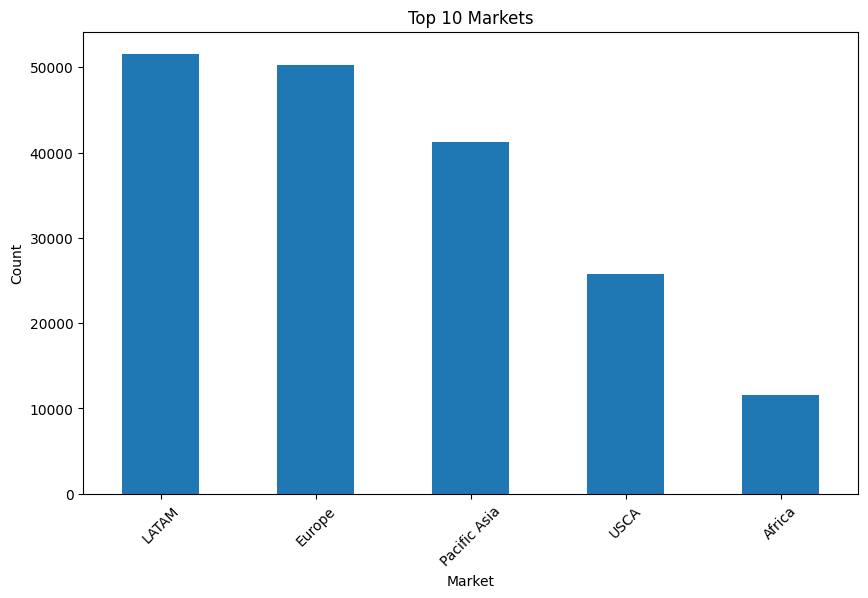

In [19]:
# Top markets
plt.figure(figsize=(10, 6))
df['Market'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Markets')
plt.xlabel('Market')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

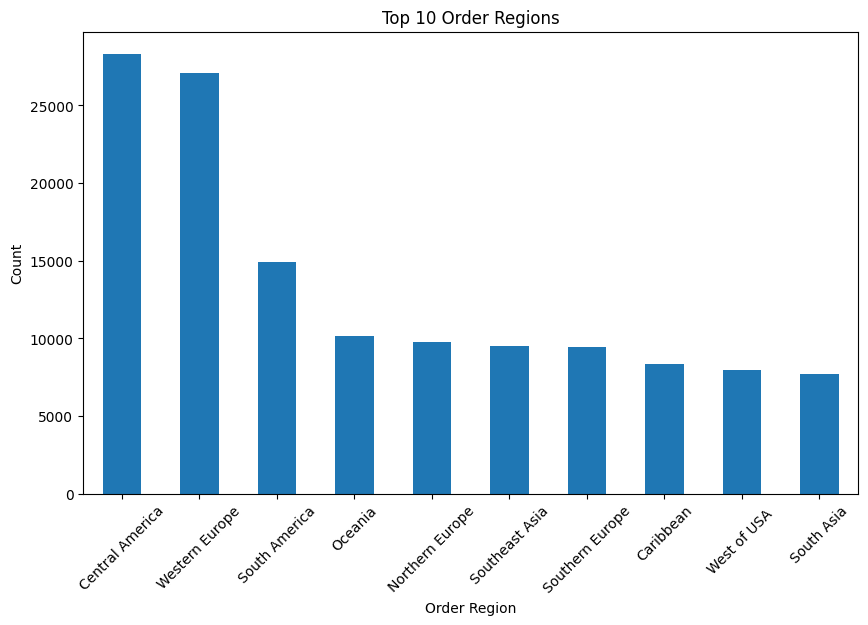

In [20]:
# Top regions
plt.figure(figsize=(10, 6))
df['Order Region'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Order Regions')
plt.xlabel('Order Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()